In [20]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # "Programming Part" auf sys.path

from env import gymnasium_env as drausp_env
import numpy as np

from env.instance_reader import get_instance_data
import matplotlib.pyplot as plt

data_path = Path("../../instances/lion18s/SA01.txt")

In [21]:
DRAUSP_data = get_instance_data(data_path)

K = DRAUSP_data.num_slots
T_d = 20  # Anzahl Anfragen pro Episode
C_k = DRAUSP_data.capacity_vector
instance = DRAUSP_data.instance
request_lengths = DRAUSP_data.request_length
pool_size = DRAUSP_data.pool_size

print(K)
print(T_d)
print(pool_size)

print(C_k)
print(instance)

4
20
50
[10, 10, 10, 10]
[[41, 1, 1, 0, 0], [39, 1, 1, 0, 0], [20, 1, 3, 0, 0], [61, 2, 1, 0, 0], [18, 2, 1, 0, 0], [23, 1, 4, 0, 0], [25, 1, 1, 0, 0], [13, 1, 1, 0, 0], [77, 1, 1, 0, 0], [8, 1, 2, 0, 0], [25, 1, 3, 0, 0], [74, 1, 1, 0, 0], [39, 1, 3, 0, 0], [54, 3, 2, 0, 0], [70, 1, 3, 0, 0], [71, 1, 1, 0, 0], [55, 1, 1, 0, 0], [9, 1, 1, 0, 0], [96, 1, 1, 0, 0], [63, 3, 2, 0, 0], [50, 3, 2, 0, 0], [20, 1, 1, 0, 0], [43, 1, 2, 0, 0], [74, 1, 2, 0, 0], [62, 1, 1, 0, 0], [60, 1, 1, 0, 0], [22, 1, 1, 0, 0], [81, 1, 2, 0, 0], [92, 1, 1, 0, 0], [80, 1, 1, 0, 0], [38, 2, 1, 0, 0], [84, 1, 1, 0, 0], [39, 1, 2, 0, 0], [88, 2, 1, 0, 0], [69, 1, 3, 0, 0], [21, 2, 1, 0, 0], [15, 1, 1, 0, 0], [47, 3, 1, 0, 0], [67, 1, 1, 0, 0], [18, 1, 1, 0, 0], [87, 1, 1, 0, 0], [58, 1, 2, 0, 0], [34, 2, 1, 0, 0], [8, 1, 1, 0, 0], [97, 1, 1, 0, 0], [73, 1, 1, 0, 0], [54, 1, 1, 0, 0], [69, 2, 1, 0, 0], [79, 1, 2, 0, 0], [9, 1, 2, 0, 0]]


In [22]:
env = drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human", fixed_request_length=request_lengths)

In [23]:
from training.dqn_agent import DQNAgent
from models.full_lattice import FullLatticeNetwork


agent = DQNAgent(
    env,
    QnetworkClass=lambda input_dim, output_dim: FullLatticeNetwork(
        input_dim     = input_dim,
        output_dim    = output_dim,
        c_range       = (0.0, 10.0),
        t_range       = (1.0, float(T_d)),
        r_range       = (0.0, 100.0),
        q_range       = (0.0, 10.0)
    ),
    monotonicity_penalty=False,
    reject_bias=0.75,
    gamma=0.99,
    epsilon_decay_steps=5000
)

In [24]:
reward_history, monotonicity_violations, depth_history = agent.train(num_episodes=4000)

  Systematic monotonicity (Episode 1): C_k: 100.0%, t: 100.0%, r: 100.0%, q: 100.0%, mixed: 100.0%
Episode   50/4000  Reward:   302.00  Avg(50):   284.92  Tiefe:   20  Avg-Tiefe(50):   19.9  ε: 0.837
  Systematic monotonicity (Episode 51): C_k: 100.0%, t: 100.0%, r: 100.0%, q: 100.0%, mixed: 100.0%
Episode  100/4000  Reward:   312.00  Avg(50):   429.08  Tiefe:   20  Avg-Tiefe(50):   19.9  ε: 0.704
  Systematic monotonicity (Episode 101): C_k: 100.0%, t: 100.0%, r: 100.0%, q: 100.0%, mixed: 100.0%
Episode  150/4000  Reward:   381.00  Avg(50):   497.20  Tiefe:   20  Avg-Tiefe(50):   19.7  ε: 0.596
  Systematic monotonicity (Episode 151): C_k: 100.0%, t: 100.0%, r: 100.0%, q: 100.0%, mixed: 100.0%
Episode  200/4000  Reward:   728.00  Avg(50):   595.50  Tiefe:   20  Avg-Tiefe(50):   19.6  ε: 0.508
  Systematic monotonicity (Episode 201): C_k: 100.0%, t: 100.0%, r: 100.0%, q: 100.0%, mixed: 100.0%
Episode  250/4000  Reward:   356.00  Avg(50):   598.60  Tiefe:   19  Avg-Tiefe(50):   18.8  ε:

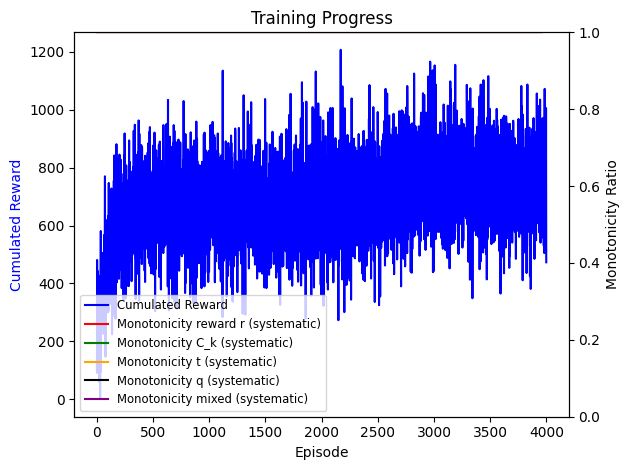

In [25]:
from training.plotting import plot_training_progress, plot_depth_epsilon

plot_training_progress(reward_history, monotonicity_violations)

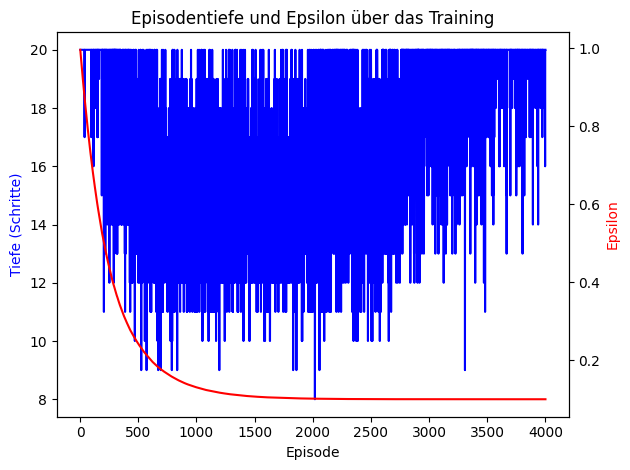

In [26]:
plot_depth_epsilon(depth_history)

Episoden: 4000
Mean: 684.8085, Std: 151.5927, Median: 686.0000
Final mean (letzte 50): 755.4000
AUC (cum. area): 2738932.5000, AUC_norm: 684.7331
Max: 1207.0000, Min: 0.0000


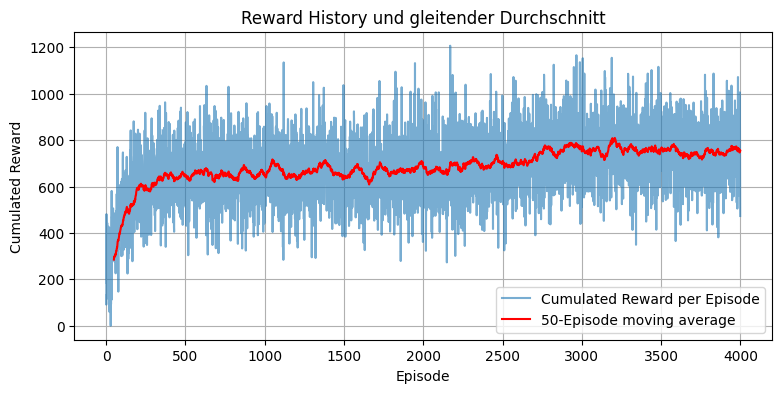

In [28]:
import numpy as np
import matplotlib.pyplot as plt

if 'reward_history' not in globals():
    print("Variable 'reward_history' nicht gefunden. Bitte die Trainingszelle ausführen und erneut ausführen.")
else:
    r = np.array(reward_history)
    n = len(r)
    mean_total = r.mean()
    std_total = r.std(ddof=1) if n>1 else 0.0
    median = np.median(r)
    final_mean = r[-50:].mean() if n>=50 else r.mean()
    auc = np.trapz(r)
    auc_norm = auc / max(1, n)
    max_r = r.max()
    min_r = r.min()

    print(f"Episoden: {n}")
    print(f"Mean: {mean_total:.4f}, Std: {std_total:.4f}, Median: {median:.4f}")
    print(f"Final mean (letzte 50): {final_mean:.4f}")
    print(f"AUC (cum. area): {auc:.4f}, AUC_norm: {auc_norm:.4f}")
    print(f"Max: {max_r:.4f}, Min: {min_r:.4f}")

    window = min(50, n)
    if n >= 2:
        mov = np.convolve(r, np.ones(window)/window, mode='valid')
        plt.figure(figsize=(9,4))
        plt.plot(r, label='Cumulated Reward per Episode', alpha=0.6)
        plt.plot(np.arange(window-1, n), mov, label=f'{window}-Episode moving average', color='red')
        plt.xlabel('Episode')
        plt.ylabel('Cumulated Reward')
        plt.title('Reward History und gleitender Durchschnitt')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print('Nicht genügend Daten zum Plotten.')

## Reward-History Analyse

Diese Zelle berechnet zentrale Kennzahlen aus `reward_history` und zeigt zusätzlich den Reward-Verlauf mit einem gleitenden Durchschnitt. Außerdem gibt sie eine einfache Diagnose zur Sprungstelle im Training aus.

Episoden: 4000
Mean: 684.8085, Std: 151.5927, Median: 686.0000
Final mean (letzte 50): 755.4000
AUC (cum. area): 2738932.5000, AUC_norm: 684.7331
Max: 1207.0000, Min: 0.0000


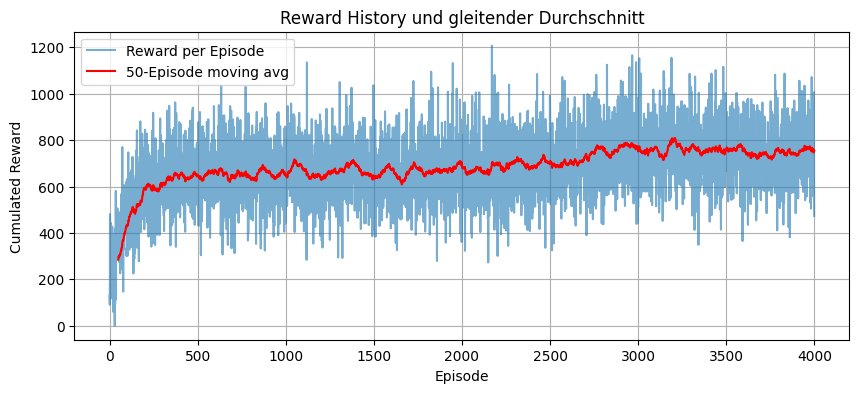

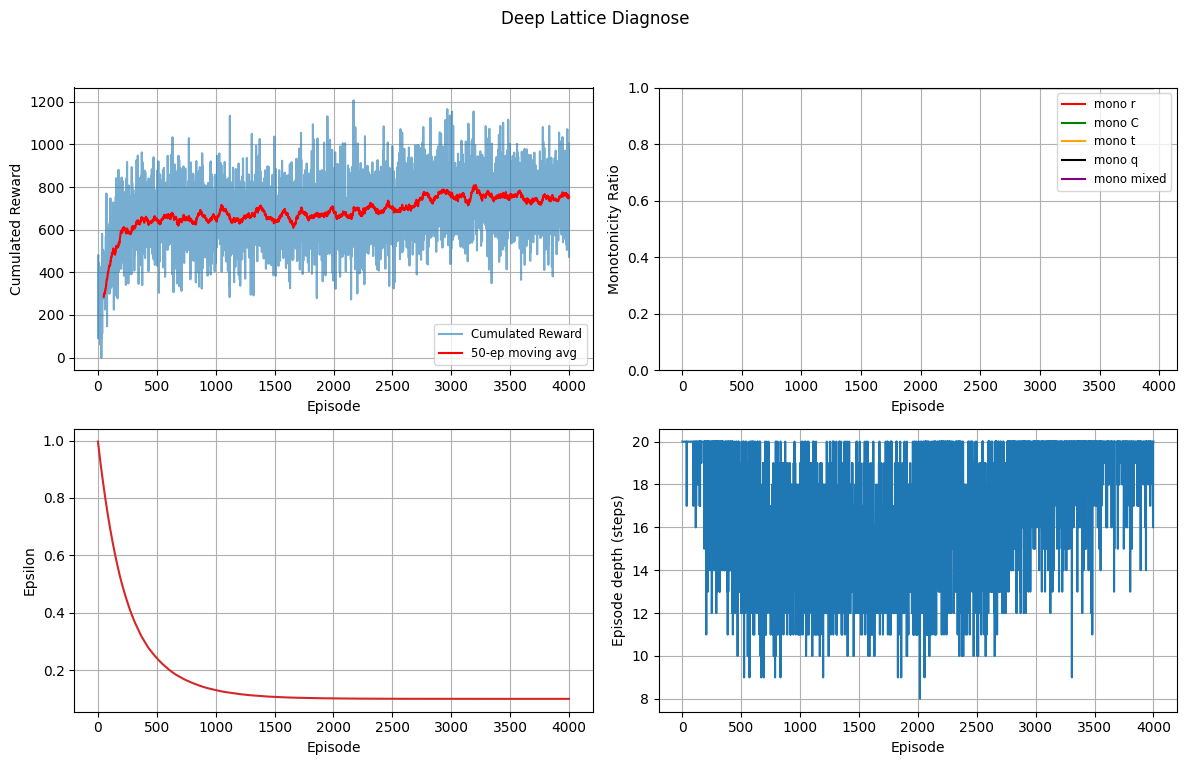

Approx. Sprung-Episode: None


In [31]:
import numpy as np
import matplotlib.pyplot as plt

def plot_training_diagnostics(reward_history, depth_history=None, monotonicity_history=None, window=50, title="Training Diagnostics"):
    """
    Erweiterte Diagnose-Plots:
      - Reward + gleitender Mittelwert, erkennt plötzlichen Sprung
      - Epsilon-Verlauf (falls `depth_history` gegeben)
      - Episodentiefe (falls `depth_history` gegeben)
      - Monotonie-Ratios (falls `monotonicity_history` gegeben)

    Parameter:
      reward_history          : Liste oder Array kumulierter Rewards pro Episode
      depth_history           : Liste von (episode, depth, epsilon)-Tupeln (optional)
      monotonicity_history    : Liste von (episode, mono_c, mono_t, mono_r, mono_q, mono_mixed)-Tupeln (optional)
      window                  : Fenstergröße für gleitenden Mittelwert
    """
    r = np.array(reward_history)
    n = len(r)

    # Gleitender Durchschnitt (valid -> length n-window+1)
    if n >= 2 and window >= 1:
        mov = np.convolve(r, np.ones(window) / window, mode='valid')
    else:
        mov = None

    # Sprungerkennung: erster Index, bei dem mov > mean + 2*std
    jump_idx = None
    if mov is not None and len(mov) > 0:
        thr = mov.mean() + 2.0 * mov.std()
        idxs = np.where(mov > thr)[0]
        if len(idxs) > 0:
            # convert mov-index to episode index (mov index i corresponds to episode i+window-1)
            jump_idx = int(idxs[0] + window - 1)

    # Layout: 2x2, einige Panels optional
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # Reward + mov
    ax_r = axes[0, 0]
    ax_r.plot(r, label='Cumulated Reward', alpha=0.6)
    if mov is not None:
        ax_r.plot(np.arange(window - 1, n), mov, label=f'{window}-ep moving avg', color='red')
    if jump_idx is not None:
        ax_r.axvline(jump_idx, color='magenta', linestyle='--', label=f'Jump ~ep {jump_idx}')
    ax_r.set_xlabel('Episode')
    ax_r.set_ylabel('Cumulated Reward')
    ax_r.legend(fontsize='small')
    ax_r.grid(True)

    # Monotonicity (optional)
    ax_m = axes[0, 1]
    if monotonicity_history is not None and len(monotonicity_history) > 0:
        episodes = [x[0] for x in monotonicity_history]
        mono_c     = [x[1] for x in monotonicity_history]
        mono_t     = [x[2] for x in monotonicity_history]
        mono_r     = [x[3] for x in monotonicity_history]
        mono_q     = [x[4] for x in monotonicity_history]
        mono_mixed = [x[5] for x in monotonicity_history]

        ax_m.plot(episodes, mono_r,     color='red',    label='mono r')
        ax_m.plot(episodes, mono_c,     color='green',  label='mono C')
        ax_m.plot(episodes, mono_t,     color='orange', label='mono t')
        ax_m.plot(episodes, mono_q,     color='black',  label='mono q')
        ax_m.plot(episodes, mono_mixed, color='purple', label='mono mixed')
        ax_m.set_ylim(0, 1)
        ax_m.set_xlabel('Episode')
        ax_m.set_ylabel('Monotonicity Ratio')
        ax_m.legend(fontsize='small')
        ax_m.grid(True)
    else:
        ax_m.text(0.5, 0.5, 'No monotonicity data', ha='center', va='center')
        ax_m.axis('off')

    # Epsilon (from depth_history)
    ax_e = axes[1, 0]
    if depth_history is not None and len(depth_history) > 0:
        eps = [x[2] for x in depth_history]
        ax_e.plot(range(1, len(eps) + 1), eps, color='tab:red')
        ax_e.set_xlabel('Episode')
        ax_e.set_ylabel('Epsilon')
        ax_e.grid(True)
    else:
        ax_e.text(0.5, 0.5, 'No depth/epsilon data', ha='center', va='center')
        ax_e.axis('off')

    # Depth
    ax_d = axes[1, 1]
    if depth_history is not None and len(depth_history) > 0:
        depths = [x[1] for x in depth_history]
        ax_d.plot(range(1, len(depths) + 1), depths, color='tab:blue')
        ax_d.set_xlabel('Episode')
        ax_d.set_ylabel('Episode depth (steps)')
        ax_d.grid(True)
    else:
        ax_d.text(0.5, 0.5, 'No depth data', ha='center', va='center')
        ax_d.axis('off')

    fig.suptitle(title)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


if 'reward_history' not in globals():
    print("Variable 'reward_history' nicht gefunden. Bitte die Trainingszelle ausführen.")
else:
    # Kennzahlen
    r = np.array(reward_history)
    n = len(r)
    mean_total = r.mean()
    std_total = r.std(ddof=1) if n > 1 else 0.0
    median = np.median(r)
    final_mean = r[-50:].mean() if n >= 50 else r.mean()
    auc = np.trapz(r)
    auc_norm = auc / max(1, n)
    max_r = r.max()
    min_r = r.min()

    print(f"Episoden: {n}")
    print(f"Mean: {mean_total:.4f}, Std: {std_total:.4f}, Median: {median:.4f}")
    print(f"Final mean (letzte 50): {final_mean:.4f}")
    print(f"AUC (cum. area): {auc:.4f}, AUC_norm: {auc_norm:.4f}")
    print(f"Max: {max_r:.4f}, Min: {min_r:.4f}")

    # Plot mit gleitendem Durchschnitt
    window = min(50, n)
    if n >= 2:
        mov = np.convolve(r, np.ones(window)/window, mode='valid')
        plt.figure(figsize=(10, 4))
        plt.plot(r, label='Reward per Episode', alpha=0.6)
        plt.plot(np.arange(window-1, n), mov, label=f'{window}-Episode moving avg', color='red')
        plt.xlabel('Episode')
        plt.ylabel('Cumulated Reward')
        plt.title('Reward History und gleitender Durchschnitt')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print('Nicht genügend Daten zum Plotten.')

    # Erweiterte Diagnose
    try:
        plot_training_diagnostics(reward_history, depth_history, monotonicity_violations, window=50, title='Deep Lattice Diagnose')
    except Exception as e:
        print('Fehler bei plot_training_diagnostics:', e)

    # Sprungerkennung
    if n >= window:
        jump_idx = None
        thr = mov.mean() + 2.0 * mov.std()
        idxs = np.where(mov > thr)[0]
        if len(idxs) > 0:
            jump_idx = int(idxs[0] + window - 1)
        print('Approx. Sprung-Episode:', jump_idx)
        if jump_idx is not None and 'depth_history' in globals():
            eps = [x[2] for x in depth_history]
            lo = max(0, jump_idx-10)
            hi = min(len(eps)-1, jump_idx+10)
            print('\nEpsilon um Sprung:')
            for i in range(lo, hi+1):
                print(f'Episode {i+1}: ε={eps[i]:.4f}')
    else:
        print('Zu wenig Episoden zur Sprung-Analyse.')